In [ ]:
# Import the FEMSystem Class from directory above
import sys
sys.path.append('../..')
from FEMSystem import FEMSystem

import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt
import numpy as np
from jax.scipy.sparse.linalg import cg

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
from scipy.optimize import curve_fit

'''
Fill in File Path
'''

heightOrSep = True # True if height, False if separation

sweep_values = [10,13,15,25,30]

heights = []
separations = []
ejs = []
ecs = []
for sweep_value in sweep_values:
    file_path = f'../allplots/heightsweep3/sep{sweep_value}/results.pkl'
    with open(file_path, 'rb') as f:
        pickled_obj = pickle.load(f)
    heights.append(pickled_obj["parameters"]["sidelenZ"])
    separations.append(pickled_obj["parameters"]["separation"])
    ejs.append(pickled_obj["E_J"])
    ecs.append(pickled_obj["E_C"])
    print(f"Finished Reading {sweep_value}")

ratios = [ejs[i]/ecs[i] for i in range(len(ejs))]

Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/ubuntu/cqednumerics/jax-gpu/lib/python3.14/site-packages/jax/_src/xla_bridge.py", line 487, in discover_pjrt_plugins
    plugin_module.initialize()
    ~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/home/ubuntu/cqednumerics/jax-gpu/lib/python3.14/site-packages/jax_plugins/xla_cuda12/__init__.py", line 370, in initialize
    _check_cuda_versions(raise_on_first_error = True)
    ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/cqednumerics/jax-gpu/lib/python3.14/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:134: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE


Finished Reading 1
Finished Reading 3
Finished Reading 5
Finished Reading 7
Finished Reading 9
Finished Reading 11
Finished Reading 13
Finished Reading 15


[Array(2.8821156, dtype=float32), Array(1.3752536, dtype=float32), Array(0.7628708, dtype=float32), Array(0.48942763, dtype=float32), Array(-0.42087552, dtype=float32), Array(0.3929987, dtype=float32), Array(0.35517728, dtype=float32), Array(0.3776265, dtype=float32)]


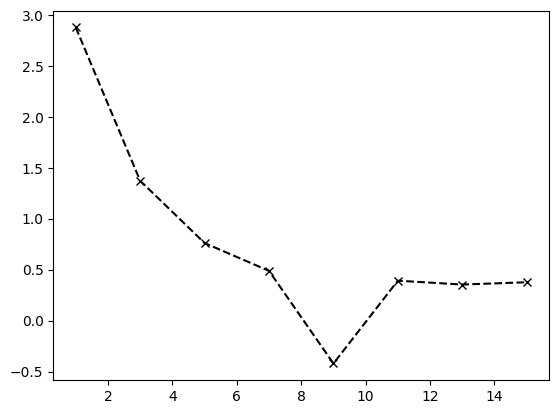

In [2]:
plt.plot(separations,ratios,"x--",color="black")
print(ratios)

Degree of Polynomial Fit: 1.3428348153456282


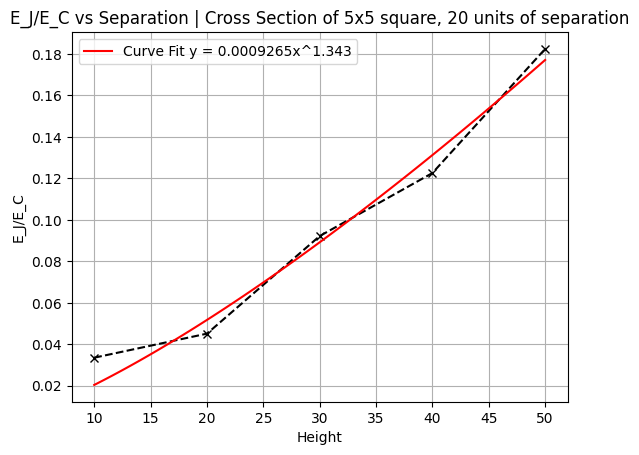

In [ ]:
def fit_curve(heights, ratios):
    # Define the function to fit
    def func(x, a, n):
        return a * (x**n)

    # Initial guess for the parameters
    initial_guess = [1, 1]

    # Perform the fit
    popt, _ = curve_fit(func, heights, ratios, p0=initial_guess)

    return popt

# heights = [10,20,30,40,50]
# ratios = [0.033529601991176605,0.045130349695682526,0.09219560027122498,0.12259875237941742,0.18245354294776917]

popt = fit_curve(heights,ratios)
xs = jnp.linspace(min(heights),max(heights),100)
ys = popt[0] * xs**popt[1]
print(f"Degree of Polynomial Fit: {popt[1]}")

plt.plot(heights,ratios,"x--",color="black")
plt.plot(xs,ys,"-",color="red",label=f"Curve Fit y = {popt[0]:.4g}x^{popt[1]:.4g}")
plt.xlabel("Height")
plt.ylabel("E_J/E_C")
plt.title("E_J/E_C vs Separation | Cross Section of 5x5 square, 20 units of separation")
plt.grid(True)
plt.legend()
plt.show()